# Clean and join `emr_oocyte` and `emr_oocyte_day`

A first-pass cleaning and joining of the oocyte tables before analysis.

What this notebook does, in order:
1. **Profile** every column (how full it is, how many distinct values, its type)
2. **Drop** columns that are completely empty
3. **Review** columns that hold only a single value
4. **Merge** the oocyte dataframes (by absolute_oocyteid)
5. **Tidy** column types
6. **Save** a cleaned copy + keep an audit note of what changed

The same `profile()` function works on the other `emr_*` tables too, so you can reuse this pattern.

> **Before running:** finish the venv setup in this repo and install the packages — open a terminal and run `pip install pandas pyarrow`. The `requirements.txt` alongside this notebook lists everything.
>
> **Important:** keep your raw patient data in a `data/` folder that is git-ignored. Don't commit EMR exports to GitHub, even a private repo.

## Setup

In [180]:
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import import_ipynb

import helper_functions

#from helper_functions import profile
#from helper_functions import drop_empty_and_constant_columns

In [181]:
# --- emr_oocyte ---
oocyte_PATH = Path("../data/emr_oocyte.csv")

# loading data
oocyte_df = pd.read_csv(oocyte_PATH)

# --- emr_oocyte_day ---
oocyte_day_PATH = Path("../data/emr_oocyte_day.csv")

# loading data
oocyte_day_df = pd.read_csv(oocyte_day_PATH)

C:\Users\tamar.schaap\AppData\Local\Temp\ipykernel_7356\4179078064.py:5: DtypeWarning: Columns (0: incubatortime) have mixed types. Specify dtype option on import or set low_memory=False.
  oocyte_df = pd.read_csv(oocyte_PATH)
C:\Users\tamar.schaap\AppData\Local\Temp\ipykernel_7356\4179078064.py:11: DtypeWarning: Columns (0: morphology, 1: uniform, 2: compaction, 3: aspherical, 4: granularcytoplasm, 5: vacuolisation, 6: ivm, 7: ah_note, 8: note, 9: cumulus, 10: fresh_donatedon, 11: pgd_performedby_other, 12: pgd_witness_other, 13: pgd_mosaic, 14: biopsy_accession_number, 15: biopsy_requisitionid, 16: pgd_karyotype, 17: pgd_mitosure, 18: pgtm_performed, 19: pgtm_technique, 20: pgtm_testmethod, 21: pgtm_indication, 22: pgtm_facility, 23: pgtm_numcells, 24: pgtm_ordered, 25: pgtm_inheritance, 26: pgtm_gene, 27: pgtm_partnervariant, 28: pgtsr_performed, 29: pgtsr_technique, 30: pgtsr_testmethod, 31: pgtsr_indication, 32: pgtsr_facility, 33: pgtsr_numcells, 34: pgtsr_ordered, 35: pgtsr_resu

In [182]:
#setting display options to show all columns and full width
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', None)        # Allow full width

## 1. Profile every column

One row per column so you can see at a glance what's worth keeping.

In [183]:
# Already know there are many all NULL columns, so dropping those first
print(oocyte_df.shape)
oocyte_df = oocyte_df.dropna(axis=1, how="all")
print(oocyte_df.shape)

print(oocyte_day_df.shape)
oocyte_day_df = oocyte_day_df.dropna(axis=1, how="all") 
print(oocyte_day_df.shape)

(61446, 43)
(61446, 36)
(178079, 138)
(178079, 95)


In [184]:
# now profiling the dataframes to get a better understanding of the data and dropping unninformative columns

oocyte_prof = helper_functions.profile(oocyte_df)
oocyte_df = helper_functions.drop_empty_and_constant_columns(oocyte_df, oocyte_prof)
print(oocyte_prof)

oocyte_day_prof = helper_functions.profile(oocyte_day_df)
oocyte_day_df = helper_functions.drop_empty_and_constant_columns(oocyte_day_df, oocyte_day_prof)
print(oocyte_day_prof)

Dropping 3 columns
                           non_null  nulls  distinct    dtype  pct_null  \
id                            61446      0     61446      str       0.0   
addedon                       61446      0     61446      str       0.0   
absolute_oocyteid             61446      0     55064      str       0.0   
patid                         61446      0      3259    int64       0.0   
max_day                       60823    623         8  float64       1.0   
donate                        60261   1185         2  float64       1.9   
ord                           58062   3384       113  float64       5.5   
eggsource_eligibility         56971   4475        16      str       7.3   
cycleid                       54469   6977      6280      str      11.4   
addedby                       54469   6977        15  float64      11.4   
aspirationid                  51706   9740      3253      str      15.9   
spermsource_eligibility       35054  26392        15      str      43.0   
icsi_t

## 2. Cleaning datasets

for example, filling in cycleids, treatment, etc.

In [185]:
# count how many missing in cycle id column
display(oocyte_df['cycleid'].isna().sum())

np.int64(6977)

### getting rid of spaces in "grade" in oocyte_day_df in case of duplicates that are not detected as such

In [186]:
# deleting spaces
oocyte_day_df["grade"] = oocyte_day_df["grade"].str.strip()

### deleting rows with grades that are outdated (they got a new grade after new biopsy)

In [187]:
# Sort by addedon so the latest row is last
oocyte_day_df = oocyte_day_df.sort_values("addedon")

# Latest non-null grade for each absolute_oocyteid
latest_grade = (
    oocyte_day_df.dropna(subset=["grade"])
    .groupby("absolute_oocyteid")["grade"]
    .last()
)

# Latest non-null stage for each absolute_oocyteid
latest_stage = (
    oocyte_day_df.dropna(subset=["stage"])
    .groupby("absolute_oocyteid")["stage"]
    .last()
)

# Fill in grade and stage
#oocyte_day_df["grade"] = oocyte_day_df["absolute_oocyteid"].map(latest_grade)
#oocyte_day_df["stage"] = oocyte_day_df["absolute_oocyteid"].map(latest_stage)

### filling in incomplete cycleid's

In [188]:
# ensuring that the "addedon" column is in datetime format and sorting the dataframe by "patid" and "addedon"
oocyte_df['addedon'] = pd.to_datetime(oocyte_df['addedon'], utc=True)
oocyte_df = oocyte_df.sort_values(['patid', 'addedon'])

for patid, idx in oocyte_df.groupby('patid').groups.items():
    group = oocyte_df.loc[idx].sort_values('addedon')

    for row_idx in group[group['cycleid'].isna()].index:
        date = oocyte_df.loc[row_idx, 'addedon']

        nearby = group[
            (group['cycleid'].notna()) &
            ((group['addedon'] - date).abs() <= pd.Timedelta(days=10))
        ]

        if len(nearby) == 1:
            oocyte_df.loc[row_idx, 'cycleid'] = nearby.iloc[0]['cycleid']
        elif len(nearby) > 1:
            closest_idx = (nearby['addedon'] - date).abs().idxmin()
            oocyte_df.loc[row_idx, 'cycleid'] = oocyte_df.loc[closest_idx, 'cycleid']

### separating df's into those for egg retrieval data and those for embryo transfer data

In [189]:
# first creating df with embryo transfer info - leaving this out for now since I filter out the embryo transfers at a later stage

# looking at all unique levels of "status"
display(oocyte_day_df["status"].unique())

## Setting aside all embryo transfers selecting status == "Embryo Transfer"
#embryo_transfer_eggs_df = oocyte_day_df[oocyte_day_df["status"] == "Embryo Transfer"]

## now dropping embryo transfer cases from oocyte_day_df
#oocyte_day_df = oocyte_day_df[oocyte_day_df["status"] != "Embryo Transfer"]

<StringArray>
[nan, 'Cryopreserved', 'Embryo Transfer', 'Discarded']
Length: 4, dtype: str

## 3. Feature Generation and Selection

Only looking to keep columns that inform response type. Filtering beyond the NA and single value columns

In [190]:
# print list of columns with their data types and percentage of nulls
# -------- oocyte_df --------
print("\nColumn summary:")
for col in oocyte_df.columns:
    non_null = oocyte_df[col].notna().sum()
    total = len(oocyte_df)
    pct_null = (total - non_null) / total * 100
    dtype = oocyte_df[col].dtype
    print(f"{col}: {dtype}, {pct_null:.1f}% null")

# -------- oocyte_day_df --------
#print("\nColumn summary:")
#for col in oocyte_day_df.columns:
#    non_null = oocyte_day_df[col].notna().sum()
#    total = len(oocyte_day_df)
#    pct_null = (total - non_null) / total * 100
#    dtype = oocyte_day_df[col].dtype
#    print(f"{col}: {dtype}, {pct_null:.1f}% null")


Column summary:
id: str, 0.0% null
addedby: float64, 11.4% null
addedon: datetime64[us, UTC], 0.0% null
deletedby: float64, 99.0% null
deletedon: str, 99.0% null
patid: int64, 0.0% null
donorid: str, 98.8% null
cycleid: str, 6.9% null
aspirationid: str, 15.9% null
treatment: str, 47.3% null
treatment_performed: str, 44.0% null
grouping: float64, 88.4% null
ord: float64, 5.5% null
thawsampleid: str, 91.6% null
semenanalysisid: str, 47.8% null
destroyed: str, 56.6% null
cryopreserved: str, 53.0% null
transferred: str, 95.6% null
recipientid: float64, 98.2% null
recipientcycleid: str, 98.2% null
donate: float64, 1.9% null
carrierid: float64, 99.7% null
carriercycleid: str, 99.7% null
max_day: float64, 1.0% null
fresh_donor_oocyte_id: str, 97.9% null
fresh_recipient_oocyte_id: str, 98.2% null
icsi_tech: float64, 43.9% null
insemination_tech: float64, 44.3% null
original_ord: float64, 96.2% null
absolute_oocyteid: str, 0.0% null
eggsource_eligibility: str, 7.3% null
spermsource_eligibility

In [191]:
# Adding information about granularity, vacuoles, stickiness, etc.
oocyte_day_df = helper_functions.add_oocyte_features(oocyte_day_df)

In [192]:
# now adding the values to each case for that absolute_oocyteid
feature_cols = [
    "granular", "vacuoles", "fragments", "inclusions", "cldga",
    "degenerating", "ser", "refractile_body", "dark", "retracted",
    "no_resistance", "sticky_or_difficult", "large_pvs", "dark_pvs",
    "fragmented_pb", "multiple_pb", "abnormal_pb_size", "ghost_pb",
    "detached_pb", "pvs_debris", "possible_parth", "pb_je"
]

# Propagate each oocyte's feature values across all rows with that oocyte ID
oocyte_day_df[feature_cols] = (
    oocyte_day_df.groupby("absolute_oocyteid")[feature_cols]
    .transform("max")
)

In [193]:
# selecting columns to keep for oocyte_df
oocyte_keep_cols = ["patid", "cycleid", "aspirationid", "treatment", 
                    "treatment_performed", "cryopreserved", "ord", 
                    "max_day", "absolute_oocyteid"]

# selecting columns to keep for oocyte_day_df
oocyte_day_keep_cols = ["absolute_oocyteid", "day", "stage", "grade", 
                        "discardreason", "oocyte_grade", "pgd_result", 
                        "pgd_note", "status", "granular", "vacuoles", 
                        "fragments", "inclusions", "cldga", "degenerating", 
                        "ser", "refractile_body", "dark", "retracted",
                        "no_resistance", "sticky_or_difficult", "large_pvs", 
                        "dark_pvs", "fragmented_pb", "multiple_pb", 
                        "abnormal_pb_size", "ghost_pb", "detached_pb", 
                        "pvs_debris", "possible_parth", "pb_je"] 

In [194]:
# filter the dataframes to keep only those columns
# -------- oocyte_df --------
oocyte_df = oocyte_df[oocyte_keep_cols]
print(f"\nAfter filtering to {len(oocyte_keep_cols)} columns: {oocyte_df.shape[1]} columns")

# -------- oocyte_day_df --------
oocyte_day_df = oocyte_day_df[oocyte_day_keep_cols]
print(f"\nAfter filtering to {len(oocyte_day_keep_cols)} columns: {oocyte_day_df.shape[1]} columns")


After filtering to 9 columns: 9 columns

After filtering to 31 columns: 31 columns


## 4. Merging oocyte datasets by absolute_oocyteid

On their own, each df is not super useful. Merging should make them more usable.

In [195]:
# merging the two dataframes on absolute_oocyteid
merged_df = pd.merge(oocyte_df, oocyte_day_df, on="absolute_oocyteid", how="inner")

In [196]:
# getting rid of spacing and making everything capitalized in "grade"
merged_df["grade"] = (
    merged_df["grade"]
    .astype(str)
    .str.replace(r"\s+", "", regex=True)  # remove all whitespace
    .str.upper()
)

# making everything lowercase in "pgd_result"
merged_df["pgd_result"] = (
    merged_df["pgd_result"]
    .str.lower()
)

In [197]:
# only keep cases where max_day = day
merged_df = merged_df[merged_df["max_day"] == merged_df["day"]]

# delete rows with no cycleid (it SEEMS** as if those cases are either 1) donor cases/GC cases which would be under the different patient chart, 2) the retrieval was done elsewhere and embryos transferred here, or 3) the retrieval was done before nAble (so still in artworks and will have to link by patient name)
merged_df = merged_df.dropna(subset=["cycleid"])

In [198]:
# find and exclude cycleid's that are not ICSI'd
# Find cycleids with an M2 oocyte on day 0 (not ICSI'd)
exclude_cycleids = merged_df.loc[
    (merged_df["max_day"] == 0) &
    (merged_df["stage"].str.lower() == "m2"),
    "cycleid"
].unique()

# Drop all rows from those cycles
merged_df = merged_df[
    ~merged_df["cycleid"].isin(exclude_cycleids)
].copy()

In [199]:
# grouping rows to represent same cases and the impute NA in "grade" and "status" to get most complete rows possible
group_cols = ["cycleid", "absolute_oocyteid", "ord", "day"]

# Fill missing grade/status within each group
for col in ["grade", "status", "pgd_result"]:
    merged_df[col] = (
        merged_df.groupby(group_cols)[col]
        .transform(lambda x: x.ffill().bfill())
    )

# getting rid of duplicate rows
merged_df = merged_df.drop_duplicates()

In [200]:
# Creating additional features in this df

# ----- getting latest grade for each absolute_oocyteid
merged_df["latest_grade"] = merged_df["absolute_oocyteid"].map(latest_grade)
merged_df["latest_grade"] = merged_df["latest_grade"].str.replace(" ", "", regex=False)

# ----- number of eggs retrieved
merged_df["n_eggs_retrieval"] = (merged_df.groupby("cycleid")["ord"].transform("max"))

# ----- number of unfertilized eggs
n_unfertilized = (merged_df.loc[merged_df["max_day"] == 0].groupby("cycleid")["absolute_oocyteid"].nunique())
merged_df["n_unfertilized"] = (merged_df["cycleid"].map(n_unfertilized).fillna(0).astype(int))

# ----- day that embryo turned into blastocyst
blast_stages = ["earlyblast", "expandedblast", "hatchingblast", "fullblast", "hatchedblast"]
merged_df["day_blastocyst"] = np.where(merged_df["stage"].str.lower().isin(blast_stages), merged_df["max_day"], pd.NA)

# ----- whether the egg fertilized or not
pn_stages = ["2pn", "3pn", "2cell", "3cell", "4cell", "5cell", "6cell",
    "7cell", "8cell", "9cell", "10cell", "11cell", "12cell", "13cell",
    "morula", "earlyblast", "expandedblast", "hatchingblast", 
    "fullblast", "hatchedblast"]
oocytes_with_2pn = (merged_df.loc[merged_df["stage"].str.lower().isin(pn_stages), "absolute_oocyteid"].unique()) # Identify oocytes that ever reached 2PN or beyond
merged_df["2_pn"] = (merged_df["absolute_oocyteid"].isin(oocytes_with_2pn).astype(int)) # Assign 1/0 across all rows for each oocyte

# ----- getting overall grade (good, fair, fair-poor, poor)
merged_df["grade_nonspecific"] = merged_df["latest_grade"].str[2:] #might be worth switching to grade instead of latest_grade?

# ----- blastocyst stage: the latest blastocyst stage before cryopreservation. options are: "earlyblast", "fullblast", "expandedblast", "hatchingblast", "hatchedblast"
blast_map = {"earlyblast": 1, "fullblast": 2, "expandedblast": 3, "hatchingblast": 4, "hatchedblast": 5}
merged_df["blastocyst_stage"] = (merged_df.groupby("absolute_oocyteid")["stage"].transform(lambda x: x.map(blast_map).max()))

# now all PGTA-related testing variables
pgd = merged_df["pgd_result"]
# Helper function: assign per absolute_oocyteid if any row matches
def any_pgd_match(mask):
    return (
        merged_df.loc[mask, "absolute_oocyteid"]
        .unique()
    )

# ----- Complex aneuploid: contains both "complex" and "aneuploid"
complex_aneuploid_ids = any_pgd_match(pgd.str.contains("complex", na=False) & pgd.str.contains("aneuploid", na=False))
merged_df["complex_aneuploid"] = merged_df["absolute_oocyteid"].isin(complex_aneuploid_ids).astype(int) # Map back to dataframe

# ----- Low mosaic: contains both "low" and "mosaic"
low_mosaic_ids = any_pgd_match(pgd.str.contains("low", na=False) & pgd.str.contains("mosaic", na=False))
merged_df["low_mosaic"] = merged_df["absolute_oocyteid"].isin(low_mosaic_ids).astype(int) # Map back to dataframe

# ----- High mosaic: contains both "high" and "mosaic"
high_mosaic_ids = any_pgd_match(pgd.str.contains("high", na=False) & pgd.str.contains("mosaic", na=False))
merged_df["high_mosaic"] = merged_df["absolute_oocyteid"].isin(high_mosaic_ids).astype(int) # Map back to dataframe

# ----- Chaotic
chaotic_ids = any_pgd_match(pgd.str.contains("chaotic", na=False))
merged_df["chaotic"] = merged_df["absolute_oocyteid"].isin(chaotic_ids).astype(int) # Map back to dataframe

# ----- Euploid: contains euploid but NOT aneuploid
euploid_ids = any_pgd_match(pgd.str.contains("euploid", na=False) & ~pgd.str.contains("aneuploid", na=False))
merged_df["euploid"] = merged_df["absolute_oocyteid"].isin(euploid_ids).astype(int) # Map back to dataframe

# ----- Aneuploid: contains aneuploid, excluding complex aneuploid cases
aneuploid_ids = any_pgd_match(pgd.str.contains("aneuploid", na=False) & ~pgd.str.contains("complex", na=False))
merged_df["aneuploid"] = merged_df["absolute_oocyteid"].isin(aneuploid_ids).astype(int) # Map back to dataframe


In [201]:
# save to csv
merged_df.to_csv("../data/ivfs_and_transfers.csv", index=False)

In [202]:
## show duplicates of group_cols
#duplicates = merged_df[
#    merged_df.duplicated(subset=group_cols, keep=False)
#]

#display(duplicates.sort_values(group_cols).head(30))

# looks like most of the duplicates are with different cycle_ids. Most likely that the egg retrieval column was not correctly labeled so they were not filtered out correctly at the earlier stage


In [203]:
## getting all rows from patid ___
#patid_136132_rows = merged_df[merged_df['patid'] == 136132]
#display(patid_136132_rows)

#patid_136132_rows_day = merged_df[merged_df['absolute_oocyteid'].isin(patid_136132_rows['absolute_oocyteid'])]
#display(patid_136132_rows_day)

# this looks like it might confirm the egg retrieval filtering explanation

### Building new organized df

patid, cycleid, ord, age_at_stim, n_eggs_at_retrieval (max(ord) per cycleid), day_blastocyst (max_day if grade = any of AAG, ABG, BAG, BBF, ACF, CAF, BCF-P, CBF-P, BBF-P, CCP, BCP, CBP, CCP, XXP, or XXF), 2pn (did they fertilize), modula (did it continue to split?), stim_duration (egg retrieval date - stim start date), grade, pgta, mosaic, complex_aneuploid

## 5. Merging with patient id's, aspirations, retrieval cycles, and IVF cycles

if grade is filled in but pgd_result is NA then pgd_result is "Untested"

patient ids: patient_map (merge by patient_id column which is patid in other dfs)

aspirations: emr_cycle_aspirations_filtered (merge by cycleid and patid)

retrieval cycles: retrieval_cycles so that I filter out the remaining FET cycles in wide_df (merge by cycleid)

wide_df: the IVF cycles we have made into the wide format (still has some remaining FET cycles in the df; merge by cycleid and patid)

In [29]:
# --- patient_map ---
map_PATH = Path("../data/patient_map.csv")

# loading data
map_df = pd.read_csv(map_PATH)

# dropping unnecesary id's
map_df = map_df[~map_df['patient_id'].isin(range(1, 9))].reset_index(drop=True) # patid 1-8 are test patients so delete them


# --- emr_cycle_aspirations_filtered ---
aspirations_PATH = Path("../data/emr_cycle_aspirations_filtered.csv")

# loading data
aspirations_df = pd.read_csv(aspirations_PATH)

# dropping unnecessary columns and id's
aspirations_df = aspirations_df.drop(columns=["complication", "note", "scrub_tech", "crna", "duration", "accession_number"])
aspirations_df = aspirations_df[~aspirations_df['patid'].isin(range(1, 9))].reset_index(drop=True) # patid 1-8 are test patients so delete them


# --- retrieval_cycles ---
retrievals_PATH = Path("../data/retrieval_cycles.csv")

# loading data
retrievals_df = pd.read_csv(retrievals_PATH)

# dropping unnecessary columns and id's
retrievals_df = retrievals_df.drop(columns=["label", "response_type"])

In [36]:
# Start from retrievals_df — this defines which cycleids to keep (drops FETs from wide_df).
# Bring in wide_df (IVF cycle counts).
final_df = retrievals_df.merge(merged_df, on='cycleid', how='left')

# Bring in aspirations (cycleid + patid).
final_df = final_df.merge(aspirations_df, on=['cycleid', 'patid'], how='left')

# Bring in patient_map (patient_id in map_df = patid elsewhere).
final_df = final_df.merge(map_df, left_on='patid', right_on='patient_id', how='left')

# getting rid of more test cases
final_df = final_df[final_df["account"].astype(str).str.match(r"^\d+$", na=False)] # first getting rid of cases where account has non-numbers in it
final_df["account"] = final_df["account"].astype(int) # making account integer
final_df = final_df[final_df["account"].notna() & (final_df["account"] >= 1336)] # everyone in patient_map below 1336 is showing as test case

In [38]:
display(final_df.sample(10))
print(final_df.shape)

,cycleid,stim_start,retrieval_date,trigger_date,patid,aspirationid,treatment,treatment_performed,cryopreserved,ord,max_day,absolute_oocyteid,day,stage,grade,discardreason,oocyte_grade,pgd_result,pgd_note,status,granular,vacuoles,fragments,inclusions,cldga,degenerating,ser,refractile_body,dark,retracted,no_resistance,sticky_or_difficult,large_pvs,dark_pvs,fragmented_pb,multiple_pb,abnormal_pb_size,ghost_pb,detached_pb,pvs_debris,possible_parth,pb_je,latest_grade,n_eggs_retrieval,n_unfertilized,day_blastocyst,2_pn,grade_nonspecific,blastocyst_stage,complex_aneuploid,low_mosaic,high_mosaic,chaotic,euploid,aneuploid,id,retrieved,retrievedby,oocytes_retrieved,denuding_performed,denuding_performedby,retrievedtech,labassistant,needle_type,patient_id,account,dob
25458,67f5938c-964e-4379-ac54-80118e47a73b,2025-04-26,2025-05-08,2025-05-06,70264.0,06f422ed-f4ea-48da-8474-8a6e2093f112,ICSI,2025-05-08 13:00:00,NaN,9.0,7.0,595fcd9b-e2ac-4884-8637-4a887b531e0c,7.0,arrested,NaN,NaN,NaN,NaN,NaN,Discarded,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,15.0,3.0,<NA>,0.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,06f422ed-f4ea-48da-8474-8a6e2093f112,2025-05-08 09:10:00,89.0,15.0,2025-05-08 12:12:00-07,37.0,309.0,3279.0,Cook Echotip 16 G,70264.0,46909,1984-10-26
25964,7ba0daa0-7598-45d7-9f7f-495cc30629b9,2025-06-07,2025-06-19,2025-06-17,77095.0,d3dd9b82-f1db-46c4-8f7f-527b7a3755be,ICSI,2025-06-19 14:48:00,NaN,1.0,6.0,c73e8e5e-37ee-4e71-aeb8-6ead257244b2,6.0,expandedblast,BBF,NaN,NaN,aneuploid monosomy 16,NaN,Cryopreserved,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BBF,12.0,4.0,6.0,1.0,F,3.0,0.0,0.0,0.0,0.0,0.0,1.0,d3dd9b82-f1db-46c4-8f7f-527b7a3755be,2025-06-19 11:14:00,3.0,12.0,2025-06-19 14:15:00-07,37.0,37.0,2487.0,Double lumen needle,77095.0,53740,1991-06-03
29410,37b189c9-9be4-42b1-b7b7-ddcc5ec7d0fe,2026-01-24,2026-02-05,2026-02-03,68163.0,6460454e-fa43-4057-aa21-5841eb0cbc2c,ICSI,2026-02-05 19:30:00,NaN,11.0,7.0,ea07da2a-051e-4fa7-89df-948660f4e348,7.0,arrested,NaN,NaN,NaN,NaN,NaN,Discarded,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,33.0,9.0,<NA>,0.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,6460454e-fa43-4057-aa21-5841eb0cbc2c,2026-02-05 16:21:00,89.0,33.0,2026-02-05 18:58:00-08,37.0,2487.0,38.0,Cook Echotip 16 G,68163.0,44808,1986-05-05
26481,0c40fbbd-fcf9-44af-8ada-a565e97434c3,2025-05-16,2025-05-27,2025-05-25,68685.0,5766b7d3-241c-4467-aa40-ffbba6b080f8,ICSI,2025-05-27 13:00:00,2025-06-01,3.0,5.0,78c6415e-0a53-4686-b4e5-4ed95cb8d4db,5.0,expandedblast,ABG,NaN,NaN,euploid,Female,Cryopreserved,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,ABG,14.0,4.0,5.0,1.0,G,3.0,0.0,0.0,0.0,0.0,1.0,0.0,5766b7d3-241c-4467-aa40-ffbba6b080f8,2025-05-27 08:07:00,90.0,14.0,2025-05-27 12:30:00-07,38.0,309.0,2487.0,Cook Echotip 16 G,68685.0,45330,1988-12-23
11053,fff9de9b-19a8-45f3-9eda-6f317109db30,2022-11-10,2022-11-22,2022-11-20,37033.0,d8e11313-6e24-4e9f-9e07-6dec649f79d0,ICSI,2022-11-22 12:40:00,2022-11-27,11.0,5.0,f55e1360-d2be-48f3-bfaf-7234665dedd1,5.0,hatchingblast,ABG,NaN,NaN,euploid,EUPLOID XX,Cryopreserved,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,ABG,14.0,3.0,5.0,1.0,G,4.0,0.0,0.0,0.0,0.0,1.0,0.0,d8e11313-6e24-4e9f-9e07-6dec649f79d0,2022-11-22 07:10:00,94.0,14.0,2022-11-22 11:56:00-08,38.0,35.0,309.0,Cook Echotip 16 G,37033.0,13678,1990-09-22
18366,25b9c83d-8c2c-4706-8fe9-e8343cf04547,2024-06-21,2024-07-04,2024-07-02,52352.0,8650f51b-91e9-4dd9-be2d-2f03f70e0595,ICSI,2024-07-04 12:05:00,2024-07-09,5.0,5.0,dbf0f2ef-117e-492c-87e2-87cb618c8e06,5.0,expandedblast,ABG,NaN,NaN,euploid,Female,Cryopreserved,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,ABG,16.0,3.0,5.0,1.0,G,3.0,0.0,0.0,0.0,0.0,1.0,0.0,8650f51b-91e9-4dd9-be2d-2f03f70e0595,2024-07-04 08:40:00,89.0,16.0,2024-07-04 11:32:00-07,287.0,31.0,35.0,Double 

(35108, 67)


In [39]:
# Correcting some of the incorrect cycle dates

corrections = {
    "aa9bac9c-96c5-492c-aae5-a54e952ef00f": {"stim_start": "2022-01-02"}, # stim_start for cycleid aa9bac9c-96c5-492c-aae5-a54e952ef00f should be "2022-01-02"
    "4ed8b64a-515a-4140-908e-8626d1c31f42": {"stim_start": "2022-04-19"}, # stim_start for cycleid 4ed8b64a-515a-4140-908e-8626d1c31f42 should be "2022-04-19"
    "1254091f-596f-4690-bc1e-5bcea625a250": {"retrieval_date": "2025-01-29", "stim_start": "2025-01-17",}, # retrieval_date for cycleid 1254091f-596f-4690-bc1e-5bcea625a250 should be "2025-01-29" and stim_start should be "2025-01-17"
    "be9f2dac-54b0-427d-b931-bd03a744af66": {"stim_start": "2025-01-16"}, # stim_start for cycleid be9f2dac-54b0-427d-b931-bd03a744af66 should be "2025-01-16"
    "da81cbe4-e218-40cf-9c31-f97da2c53369": {"stim_start": "2025-10-24"}, # stim_start for cycleid da81cbe4-e218-40cf-9c31-f97da2c53369 should be "2025-10-24"
}

for cycleid, updates in corrections.items():
    mask = final_df["cycleid"] == cycleid
    for col, value in updates.items():
        final_df.loc[mask, col] = value

# Make sure all columns are datetimes
final_df["retrieved"] = pd.to_datetime(final_df["retrieved"], errors="coerce")
final_df["retrieval_date"] = pd.to_datetime(final_df["retrieval_date"], errors="coerce")
final_df["stim_start"] = pd.to_datetime(final_df["stim_start"], errors="coerce") # to calculate stim duration
final_df["dob"] = pd.to_datetime(final_df["dob"]) # to calculate age at stim start

# trigger_date = retrieval_date - 2
final_df["retrieval_date"] = final_df["retrieval_date"].fillna(final_df["retrieved"])
final_df["trigger_date"] = final_df["retrieval_date"] - pd.Timedelta(days=2) 

# calculating age at stim start
final_df["age_at_stim"] = ((final_df["stim_start"] - final_df["dob"]).dt.days / 365.25).round().astype("Int64")


In [40]:
# Filling in NA where I can in retrieval_date
print("retrieved NA:", final_df["retrieved"].isna().sum())
print("retrieval_date NA:", final_df["retrieval_date"].isna().sum())

# Fill missing retrieval_date with the date from retrieved
final_df["retrieval_date"] = final_df["retrieval_date"].fillna(
    final_df["retrieved"].dt.normalize()
)

print("retrieved NA:", final_df["retrieved"].isna().sum())
print("retrieval_date NA:", final_df["retrieval_date"].isna().sum())

# now creating stim_duration column (duration = retrieval date - stim_start)
final_df["stim_duration"] = (final_df["retrieval_date"] - final_df["stim_start"]).dt.days

# dropping duplicate rows
final_df = final_df.drop_duplicates()

retrieved NA: 135
retrieval_date NA: 35
retrieved NA: 135
retrieval_date NA: 35


In [48]:
# Drop exact duplicate rows
final_df = final_df.drop_duplicates()

# Drop rows with missing retrieval_date
final_df = final_df.dropna(subset=["retrieval_date"])

## 6. Now filtering df for a tailored df for modeling

In [89]:
# renaming df for final step
model_df = final_df.copy()

# now keeping subset of columns
cols_to_keep = [
    "patid", "cycleid", "ord", "grade", "granular", "vacuoles", "fragments", "inclusions",
    "cldga", "degenerating", "ser", "refractile_body", "dark", "retracted", "no_resistance",
    "sticky_or_difficult", "large_pvs", "dark_pvs", "fragmented_pb", "multiple_pb",
    "abnormal_pb_size", "ghost_pb", "detached_pb", "pvs_debris", "possible_parth", "pb_je",
    "n_eggs_retrieval", "n_unfertilized", "day_blastocyst", "2_pn", "grade_nonspecific",
    "blastocyst_stage", "complex_aneuploid", "low_mosaic", "high_mosaic", "chaotic",
    "euploid", "aneuploid", "needle_type", "age_at_stim", "stim_duration"
]

model_df = (
    final_df[cols_to_keep]
    .drop_duplicates()
    .reset_index(drop=True)
)

In [90]:
# now cleaning some columns for entering into a model

# ----- Cleaning needle_type
# Make needle_type lowercase and remove extra spaces
model_df["needle_type"] = (
    model_df["needle_type"]
    .astype("string")
    .str.strip()
    .str.lower()
)

# now applying my helper function
model_df["needle_type_cleaned"] = (model_df["needle_type"].apply(helper_functions.clean_needle_type))

# Encode as integers
needle_map = {
    "single lumen": 1, "single and double lumen": 2, "double lumen": 3
}

model_df["needle_type_cleaned"] = (model_df["needle_type_cleaned"].map(needle_map))

# ----- Cleaning grade
model_df = model_df[model_df["grade_nonspecific"].isin(["G", "F", "F-P", "P"])]

# Encode as integers
grade_map = {
    "G": 1, "F": 2, "F-P": 3, "P": 4
}

model_df["grade_nonspecific"] = (model_df["grade_nonspecific"].map(grade_map))

# ----- Cleaning day_blastocyst
# filling day_blastocyst_model with a meaningful value so that I do not lose all my data with missing values
model_df["day_blastocyst_model"] = (model_df["day_blastocyst"].fillna(0))

In [93]:
model_df["grade_nonspecific"].value_counts().sort_index()

grade_nonspecific
1    4666
2    4055
3    2927
4    1900
Name: count, dtype: int64

In [165]:
display(model_df.sample(8))
print(model_df.shape)

,patid,cycleid,ord,grade,granular,vacuoles,fragments,inclusions,cldga,degenerating,ser,refractile_body,dark,retracted,no_resistance,sticky_or_difficult,large_pvs,dark_pvs,fragmented_pb,multiple_pb,abnormal_pb_size,ghost_pb,detached_pb,pvs_debris,possible_parth,pb_je,n_eggs_retrieval,n_unfertilized,day_blastocyst,2_pn,grade_nonspecific,blastocyst_stage,complex_aneuploid,low_mosaic,high_mosaic,chaotic,euploid,aneuploid,needle_type,age_at_stim,stim_duration,needle_type_cleaned,day_blastocyst_model
7147,48947.0,aa3778d1-db2a-4ed5-b9e0-b44892fa3f4e,1.0,ABG,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,16.0,0.0,5.0,1.0,1,3.0,0.0,0.0,0.0,0.0,1.0,0.0,cook echotip 16 g,37,11.0,1.0,5.0
6189,45948.0,fcace429-6940-4db8-895f-c81abac5e51a,29.0,BBF,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,42.0,4.0,5.0,1.0,2,2.0,0.0,1.0,0.0,0.0,0.0,0.0,cook echotip 16 g,31,12.0,1.0,5.0
8147,30506.0,721024d5-e6fd-4da4-8134-b0e02c9ec828,6.0,BBF,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11.0,3.0,5.0,1.0,2,1.0,1.0,0.0,0.0,0.0,0.0,0.0,cook echotip 16 g,37,13.0,1.0,5.0
18664,11123.0,0b3c4051-0e43-4645-9bca-fd47433fefec,1.0,BCF-P,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0,6.0,1.0,3,2.0,0.0,0.0,0.0,0.0,1.0,0.0,double lumen needle,28,11.0,3.0,6.0
3227,13227.0,bb0cc538-7893-45af-b44c-31942504720c,3.0,BCF-P,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,0.0,6.0,1.0,3,1.0,0.0,0.0,0.0,1.0,0.0,1.0,cook echotip 16 g,42,13.0,1.0,6.0
8991,39773.0,9985ba82-b3bf-4d5b-8296-fce57f65e4ee,11.0,BBF-P,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,21.0,3.0,6.0,1.0,3,3.0,0.0,0.0,0.0,0.0,1.0,0.0,cook echotip 16 g,33,12.0,1.0,6.0
20085,56602.0,2f709efc-f0cb-4767-8a49-2d0802397cd0,9.0,BBF,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,24.0,8.0,6.0,1.0,2,3.0,0.0,0.0,0.0,0.0,0.0,0.0,cook echotip 16 g,39,12.0,1.0,6.0
32177,137089.0,d587cdf0-9384-4f66-9d7c-bd7f5ba601fe,9.0,ABG,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,33.0,2.0,5.0,1.0,1,2.0,0.0,0.0,0.0,0.0,1.0,0.0,cook echotip 16 g,36,12.0,1.0,5.0


(13548, 43)


In [172]:
model_df["grade"].value_counts()

grade
BBF      3386
ABG      2985
BCF-P    2761
AAG      1049
BAG       650
ACF       501
CCP       348
BCP       261
CBF-P      71
CBP        15
CAF        12
BBF-P       9
BCF         4
BBG         2
XXP         1
BBP         1
XXF         1
Name: count, dtype: int64

## 7. Prediction of Euploid status

In [155]:
#from sklearn.model_selection import train_test_split
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier


features = [
    'granular', 'vacuoles', 'fragments', 'inclusions', 'cldga', 'degenerating',
    'ser', 'refractile_body', 'dark', 'retracted', 'no_resistance',
    'abnormal_pb_size', 'large_pvs', 'dark_pvs', 'fragmented_pb', 'multiple_pb',
    'sticky_or_difficult', 'ghost_pb', 'detached_pb', 'pvs_debris',
    'pb_je', 'n_eggs_retrieval', 'age_at_stim', 'stim_duration', 
    'needle_type_cleaned' # 'possible_parth' is only ever 0
]

model_data = (
    model_df[features + ["patid", "euploid"]]
    .dropna()
    .reset_index(drop=True)
)

X = model_data[features]
y = model_data["euploid"]
groups = model_data["patid"]

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(gss.split(X, y, groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

In [156]:
train_patients = set(model_data.iloc[train_idx]["patid"])
test_patients = set(model_data.iloc[test_idx]["patid"])

len(train_patients.intersection(test_patients))

0

In [158]:
# Logistic Regression

log_reg = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        solver="lbfgs"
    ))
])

log_reg.fit(X_train, y_train)

log_reg_pred = log_reg.predict(X_test)
log_reg_prob = log_reg.predict_proba(X_test)[:,1]

In [159]:
# Random Forest

rf = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestClassifier(
        n_estimators=500,
        random_state=42,
        class_weight="balanced",
        max_depth=None
    ))
])

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:,1]

In [160]:
# Neural Network

nn = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPClassifier(
        hidden_layer_sizes=(64,32),
        activation="relu",
        max_iter=500,
        random_state=42
    ))
])

nn.fit(X_train, y_train)

nn_pred = nn.predict(X_test)
nn_prob = nn.predict_proba(X_test)[:,1]

In [161]:
# Comparing Performance Metrics

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

models = {
    "Logistic Regression": (log_reg_pred, log_reg_prob),
    "Random Forest": (rf_pred, rf_prob),
    "Neural Network": (nn_pred, nn_prob)
}

for name, (pred, prob) in models.items():

    # confusion matrix for this model
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()

    # metrics for this model
    roc_auc = roc_auc_score(y_test, prob)
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    sensitivity = recall_score(y_test, pred)
    specificity = tn / (tn + fp)
    f1 = f1_score(y_test, pred)
    npv = tn / (tn + fn)

    print("\n" + "="*50)
    print(name)
    print("="*50)

    print(f"ROC-AUC: {roc_auc:.3f}")
    print(f"Accuracy: {accuracy:.3f}")
    print(f"Precision (PPV): {precision:.3f}")
    print(f"Sensitivity (Recall): {sensitivity:.3f}")
    print(f"Specificity: {specificity:.3f}")
    print(f"F1-score: {f1:.3f}")
    print(f"Negative Predictive Value: {npv:.3f}")

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, pred))

    print("\nClassification Report:")
    print(classification_report(y_test, pred))


Logistic Regression
ROC-AUC: 0.625
Accuracy: 0.593
Precision (PPV): 0.454
Sensitivity (Recall): 0.591
Specificity: 0.594
F1-score: 0.514
Negative Predictive Value: 0.717

Confusion Matrix:
[[1044  715]
 [ 412  595]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.72      0.59      0.65      1759
         1.0       0.45      0.59      0.51      1007

    accuracy                           0.59      2766
   macro avg       0.59      0.59      0.58      2766
weighted avg       0.62      0.59      0.60      2766


Random Forest
ROC-AUC: 0.580
Accuracy: 0.565
Precision (PPV): 0.414
Sensitivity (Recall): 0.464
Specificity: 0.624
F1-score: 0.437
Negative Predictive Value: 0.670

Confusion Matrix:
[[1097  662]
 [ 540  467]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.67      0.62      0.65      1759
         1.0       0.41      0.46      0.44      1007

    accuracy                     

In [162]:
# looking at feature importance

# Get coefficients
coef = pd.Series(
    log_reg.named_steps["model"].coef_[0],
    index=X_train.columns
)

# Sort by absolute importance
coef_sorted = coef.reindex(
    coef.abs().sort_values(ascending=False).index
)

coef_sorted

# age_at_stim: OR = e^-.461 = .63 -> For every 1-year increase in age, the odds of euploidy decrease by approximately 37%, holding other variables constant.
# dark_pvs: OR = e^-.160 = 0.85 -> Presence of dark perivitelline space is associated with ~15% lower odds of euploidy.
# detached_pb: OR = e^ -.096 = .91 -> Detached polar body is associated with ~9% lower odds of euploidy.

age_at_stim           -0.461346
dark_pvs              -0.160013
detached_pb           -0.095673
inclusions             0.061555
vacuoles               0.038538
pvs_debris            -0.031029
abnormal_pb_size      -0.027126
sticky_or_difficult    0.025146
stim_duration         -0.024431
large_pvs              0.023450
granular              -0.020594
cldga                 -0.018028
no_resistance         -0.017474
dark                   0.016498
needle_type_cleaned   -0.015691
retracted             -0.015192
fragmented_pb         -0.014175
n_eggs_retrieval      -0.012340
ser                    0.011478
fragments             -0.007486
multiple_pb           -0.006777
pb_je                  0.004946
refractile_body        0.004694
degenerating          -0.001264
ghost_pb              -0.000144
dtype: float64

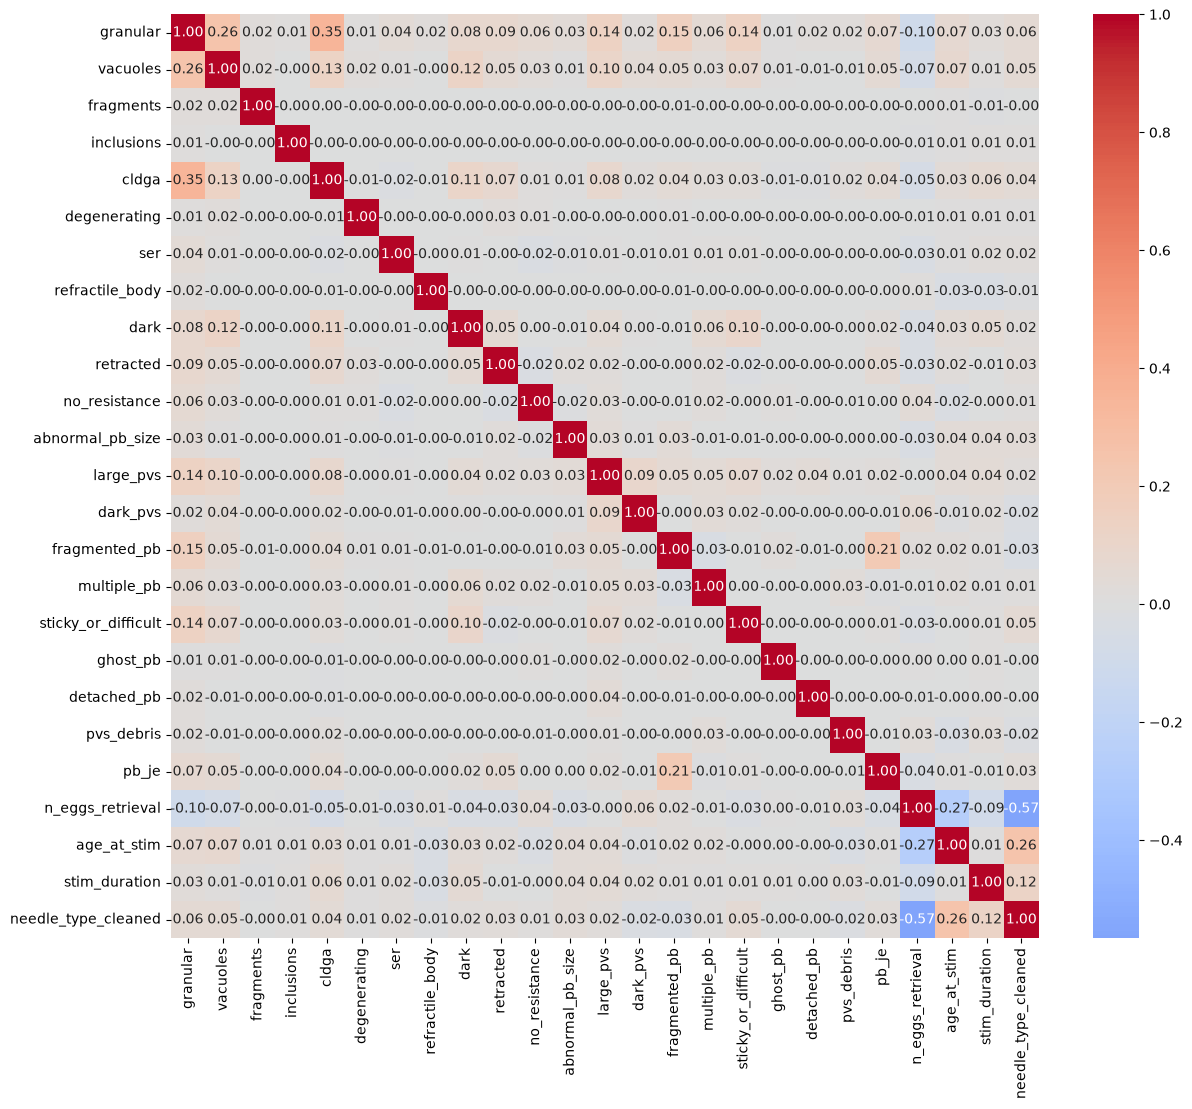

In [163]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = model_data[features].corr()

plt.figure(figsize=(14,12))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f"
)
plt.show()

## 8. Prediction of Aneuploid Status

In [171]:
# ----- Preparing the data for modeling
model_data = (
    model_df[features + ["patid", "low_mosaic"]]
    .dropna()
    .reset_index(drop=True)
)

X = model_data[features]
y = model_data["low_mosaic"]
groups = model_data["patid"]

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(gss.split(X, y, groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

# ----- Logistic Regression

log_reg = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        solver="lbfgs"
    ))
])

log_reg.fit(X_train, y_train)

log_reg_pred = log_reg.predict(X_test)
log_reg_prob = log_reg.predict_proba(X_test)[:,1]

# ----- Random Forest

rf = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestClassifier(
        n_estimators=500,
        random_state=42,
        class_weight="balanced",
        max_depth=None
    ))
])

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:,1]

# ----- Neural Network

nn = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPClassifier(
        hidden_layer_sizes=(64,32),
        activation="relu",
        max_iter=500,
        random_state=42
    ))
])

nn.fit(X_train, y_train)

nn_pred = nn.predict(X_test)
nn_prob = nn.predict_proba(X_test)[:,1]

# ----- Performance Metrics
models = {
    "Logistic Regression": (log_reg_pred, log_reg_prob),
    "Random Forest": (rf_pred, rf_prob),
    "Neural Network": (nn_pred, nn_prob)
}

for name, (pred, prob) in models.items():

    # confusion matrix for this model
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()

    # metrics for this model
    roc_auc = roc_auc_score(y_test, prob)
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    sensitivity = recall_score(y_test, pred)
    specificity = tn / (tn + fp)
    f1 = f1_score(y_test, pred)
    npv = tn / (tn + fn)

    print("\n" + "="*50)
    print(name)
    print("="*50)

    print(f"ROC-AUC: {roc_auc:.3f}")
    print(f"Accuracy: {accuracy:.3f}")
    print(f"Precision (PPV): {precision:.3f}")
    print(f"Sensitivity (Recall): {sensitivity:.3f}")
    print(f"Specificity: {specificity:.3f}")
    print(f"F1-score: {f1:.3f}")
    print(f"Negative Predictive Value: {npv:.3f}")

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, pred))

    print("\nClassification Report:")
    print(classification_report(y_test, pred))

# ----- looking at feature importance

# Get coefficients
coef = pd.Series(
    log_reg.named_steps["model"].coef_[0],
    index=X_train.columns
)

# Sort by absolute importance
coef_sorted = coef.reindex(
    coef.abs().sort_values(ascending=False).index
)

coef_sorted



Logistic Regression
ROC-AUC: 0.566
Accuracy: 0.557
Precision (PPV): 0.058
Sensitivity (Recall): 0.522
Specificity: 0.559
F1-score: 0.104
Negative Predictive Value: 0.958

Confusion Matrix:
[[1469 1161]
 [  65   71]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.96      0.56      0.71      2630
         1.0       0.06      0.52      0.10       136

    accuracy                           0.56      2766
   macro avg       0.51      0.54      0.40      2766
weighted avg       0.91      0.56      0.68      2766


Random Forest
ROC-AUC: 0.564
Accuracy: 0.882
Precision (PPV): 0.043
Sensitivity (Recall): 0.066
Specificity: 0.924
F1-score: 0.052
Negative Predictive Value: 0.950

Confusion Matrix:
[[2430  200]
 [ 127    9]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.95      0.92      0.94      2630
         1.0       0.04      0.07      0.05       136

    accuracy                     

age_at_stim           -0.312938
pvs_debris            -0.197899
refractile_body       -0.131845
large_pvs             -0.127218
stim_duration         -0.107090
detached_pb           -0.106945
degenerating          -0.103471
ghost_pb              -0.102911
abnormal_pb_size      -0.102321
inclusions            -0.058252
vacuoles              -0.045836
dark_pvs              -0.045204
pb_je                  0.042333
granular               0.041535
fragments              0.040429
ser                    0.034532
cldga                  0.034034
retracted              0.031459
needle_type_cleaned    0.026679
n_eggs_retrieval       0.022319
no_resistance         -0.017944
dark                  -0.007807
sticky_or_difficult    0.007040
multiple_pb           -0.003928
fragmented_pb         -0.001846
dtype: float64

## 9. Ploidy outcomes by Grade

are poorer grades more likely to end in mosaic, aneuploid, etc.?

ploidy_outcome  aneuploid  complex_aneuploid  euploid  high_mosaic  low_mosaic
grade                                                                         
AAG                 166.0               50.0    700.0         18.0        40.0
ABG                 677.0              298.0   1517.0        107.0       165.0
BAG                 145.0               63.0    355.0         20.0        29.0
BBF                 956.0              490.0   1314.0        130.0       187.0
ACF                 127.0              109.0    161.0         19.0        22.0
CAF                   1.0                1.0      8.0          0.0         1.0
BCF-P               792.0              586.0    686.0         86.0       156.0
CBF-P                18.0                8.0     31.0          2.0         4.0
BBF-P                 5.0                0.0      1.0          0.0         2.0
CCP                   2.0                1.0      0.0          0.0         0.0
BCP                  79.0               55.0     54.

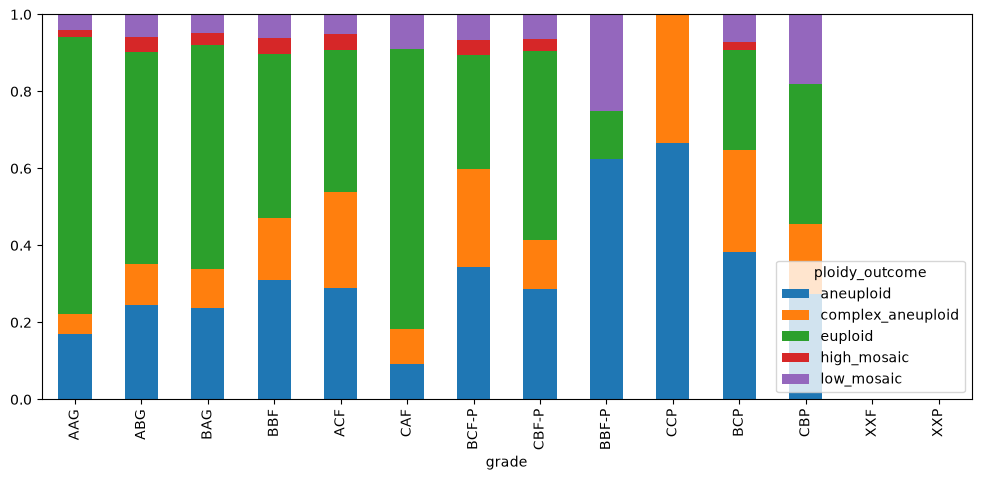

In [176]:
# If ploidy outcomes are separate binary cols and mutually exclusive:
outcomes = ['euploid', 'aneuploid', 'complex_aneuploid', 'low_mosaic', 'high_mosaic']
model_df['ploidy_outcome'] = model_df[outcomes].idxmax(axis=1)
# (if a row has all zeros, idxmax picks the first — filter to tested embryos first)
tested = model_df[model_df[outcomes].sum(axis=1) > 0].copy()

# Row-normalized proportions per grade
tab = pd.crosstab(tested['grade'], tested['ploidy_outcome'], normalize='index')

# Stacked bar
grade_order = ['AAG','ABG','BAG','BBF','ACF','CAF',
               'BCF-P','CBF-P','BBF-P','CCP','BCP','CBP','XXF','XXP']
tab.reindex(grade_order).plot(kind='bar', stacked=True, figsize=(12, 5))

# Ordinal suffix collapse — order matters: F-P before F
tested['quality'] = tested['grade'].str.extract(r'(G|F-P|F|P)$')
tab_q = pd.crosstab(tested['quality'], tested['ploidy_outcome'], normalize='index')
tab_q = tab_q.reindex(['G','F','F-P','P'])

# Also useful: raw counts alongside proportions so you see the denominators
counts = pd.crosstab(tested['grade'], tested['ploidy_outcome'])
print(counts.reindex(grade_order))

# Chi-square
from scipy.stats import chi2_contingency
chi2, p, dof, _ = chi2_contingency(counts)
print(f"chi2={chi2:.1f}, p={p:.2e}")

# Age-adjusted logistic (per outcome)
import statsmodels.formula.api as smf
for outcome in outcomes:
    m = smf.logit(f"{outcome} ~ C(quality, Treatment('G')) + age_at_stim", data=tested).fit(disp=0)
    print(f"\n--- {outcome} ---")
    print(m.summary().tables[1])

In [204]:
display(model_df.head())


,patid,cycleid,ord,grade,granular,vacuoles,fragments,inclusions,cldga,degenerating,ser,refractile_body,dark,retracted,no_resistance,sticky_or_difficult,large_pvs,dark_pvs,fragmented_pb,multiple_pb,abnormal_pb_size,ghost_pb,detached_pb,pvs_debris,possible_parth,pb_je,n_eggs_retrieval,n_unfertilized,day_blastocyst,2_pn,grade_nonspecific,blastocyst_stage,complex_aneuploid,low_mosaic,high_mosaic,chaotic,euploid,aneuploid,needle_type,age_at_stim,stim_duration,needle_type_cleaned,day_blastocyst_model,ploidy_outcome
0,40333.0,0554fe39-755c-4a1f-93cc-1ce7863c492e,1.0,ABG,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.0,0.0,5.0,1.0,1,3.0,0.0,0.0,0.0,0.0,1.0,0.0,cook echotip 16 g,36,13.0,1.0,5.0,euploid
1,40333.0,0554fe39-755c-4a1f-93cc-1ce7863c492e,2.0,ABG,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.0,0.0,5.0,1.0,1,3.0,0.0,0.0,0.0,0.0,1.0,0.0,cook echotip 16 g,36,13.0,1.0,5.0,euploid
2,40333.0,0554fe39-755c-4a1f-93cc-1ce7863c492e,3.0,ABG,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.0,0.0,5.0,1.0,1,3.0,0.0,0.0,0.0,0.0,1.0,0.0,cook echotip 16 g,36,13.0,1.0,5.0,euploid
3,40333.0,0554fe39-755c-4a1f-93cc-1ce7863c492e,4.0,ACF,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.0,0.0,5.0,1.0,2,4.0,0.0,0.0,0.0,0.0,0.0,0.0,cook echotip 16 g,36,13.0,1.0,5.0,euploid
4,40333.0,0554fe39-755c-4a1f-93cc-1ce7863c492e,5.0,BCF-P,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.0,0.0,5.0,1.0,3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,cook echotip 16 g,36,13.0,1.0,5.0,euploid


In [206]:
display(model_df.columns)

Index(['patid', 'cycleid', 'ord', 'grade', 'granular', 'vacuoles', 'fragments',
       'inclusions', 'cldga', 'degenerating', 'ser', 'refractile_body', 'dark',
       'retracted', 'no_resistance', 'sticky_or_difficult', 'large_pvs',
       'dark_pvs', 'fragmented_pb', 'multiple_pb', 'abnormal_pb_size',
       'ghost_pb', 'detached_pb', 'pvs_debris', 'possible_parth', 'pb_je',
       'n_eggs_retrieval', 'n_unfertilized', 'day_blastocyst', '2_pn',
       'grade_nonspecific', 'blastocyst_stage', 'complex_aneuploid',
       'low_mosaic', 'high_mosaic', 'chaotic', 'euploid', 'aneuploid',
       'needle_type', 'age_at_stim', 'stim_duration', 'needle_type_cleaned',
       'day_blastocyst_model', 'ploidy_outcome'],
      dtype='str')

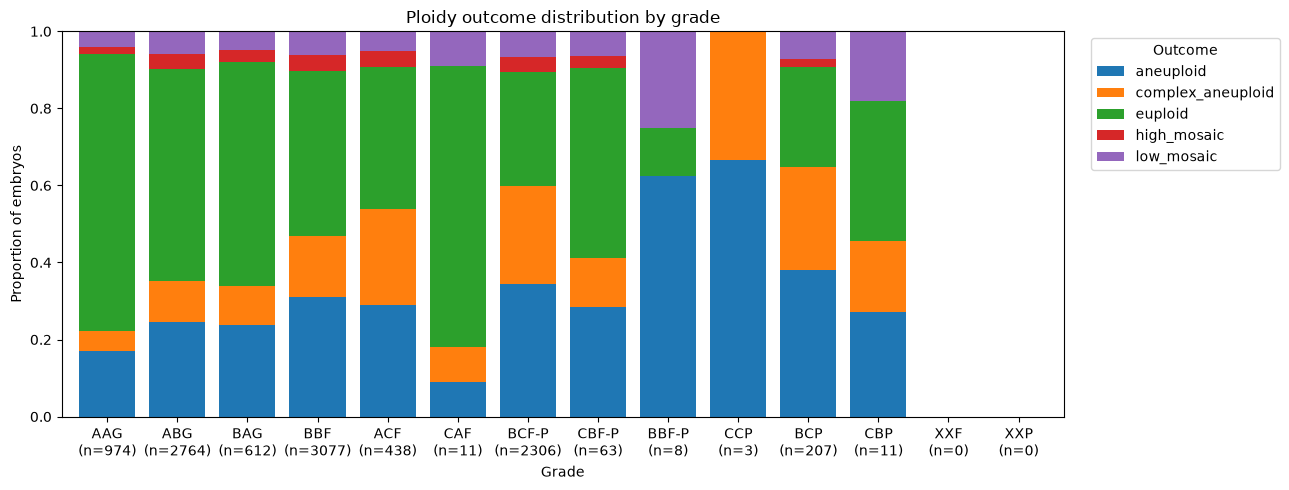

In [177]:
import matplotlib.pyplot as plt

grade_order = ['AAG','ABG','BAG','BBF','ACF','CAF',
               'BCF-P','CBF-P','BBF-P','CCP','BCP','CBP','XXF','XXP']

# Row-normalized proportions + raw counts per grade
tab    = pd.crosstab(tested['grade'], tested['ploidy_outcome'], normalize='index').reindex(grade_order)
counts = pd.crosstab(tested['grade'], tested['ploidy_outcome']).reindex(grade_order)
n_per_grade = counts.sum(axis=1)

# Plot
fig, ax = plt.subplots(figsize=(13, 5))
tab.plot(kind='bar', stacked=True, ax=ax, width=0.8)

# X-tick labels: "GRADE\n(n=###)"
ax.set_xticklabels(
    [f"{g}\n(n={int(n_per_grade.loc[g])})" for g in grade_order],
    rotation=0
)

ax.set_ylabel("Proportion of embryos")
ax.set_xlabel("Grade")
ax.set_title("Ploidy outcome distribution by grade")
ax.set_ylim(0, 1)
ax.legend(title="Outcome", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

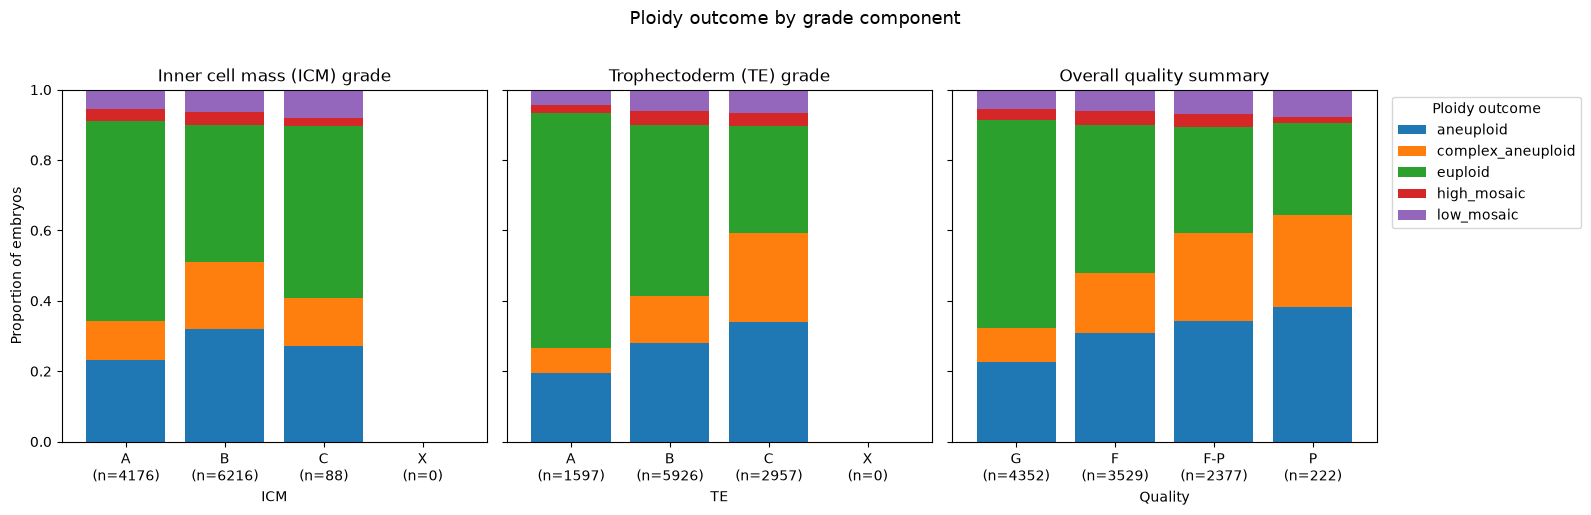

In [179]:
import matplotlib.pyplot as plt
import pandas as pd

# --- Split the grade into its three components ---
tested = tested.copy()
tested['icm']     = tested['grade'].str[0]              # A / B / C / X
tested['te']      = tested['grade'].str[1]              # A / B / C / X
tested['quality'] = tested['grade'].str.extract(r'(G|F-P|F|P)$')

# Ordered categories (best -> worst)
icm_order     = ['A', 'B', 'C', 'X']
te_order      = ['A', 'B', 'C', 'X']
quality_order = ['G', 'F', 'F-P', 'P']

# Use the SAME outcome column order as the earlier plot so colors line up.
# `tab` from the previous plot already has the canonical order; reuse it.
outcome_order = list(tab.columns)

def build_tables(col, order):
    props  = pd.crosstab(tested[col], tested['ploidy_outcome'], normalize='index').reindex(order)
    counts = pd.crosstab(tested[col], tested['ploidy_outcome']).reindex(order)
    # Ensure all outcomes are present as columns, in the same order, filled with 0 if missing
    props  = props.reindex(columns=outcome_order, fill_value=0)
    return props, counts.sum(axis=1)

icm_props,  icm_n  = build_tables('icm',     icm_order)
te_props,   te_n   = build_tables('te',      te_order)
qual_props, qual_n = build_tables('quality', quality_order)

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

panels = [
    (axes[0], icm_props,  icm_n,  icm_order,     "Inner cell mass (ICM) grade", "ICM"),
    (axes[1], te_props,   te_n,   te_order,      "Trophectoderm (TE) grade",    "TE"),
    (axes[2], qual_props, qual_n, quality_order, "Overall quality summary",     "Quality"),
]

for ax, props, n, order, title, xlabel in panels:
    props.plot(kind='bar', stacked=True, ax=ax, width=0.8, legend=False)
    ax.set_xticklabels(
        [f"{g}\n(n={int(n.loc[g])})" if pd.notna(n.loc[g]) else f"{g}\n(n=0)"
         for g in order],
        rotation=0,
    )
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylim(0, 1)

axes[0].set_ylabel("Proportion of embryos")
axes[-1].legend(title="Ploidy outcome", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.suptitle("Ploidy outcome by grade component", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

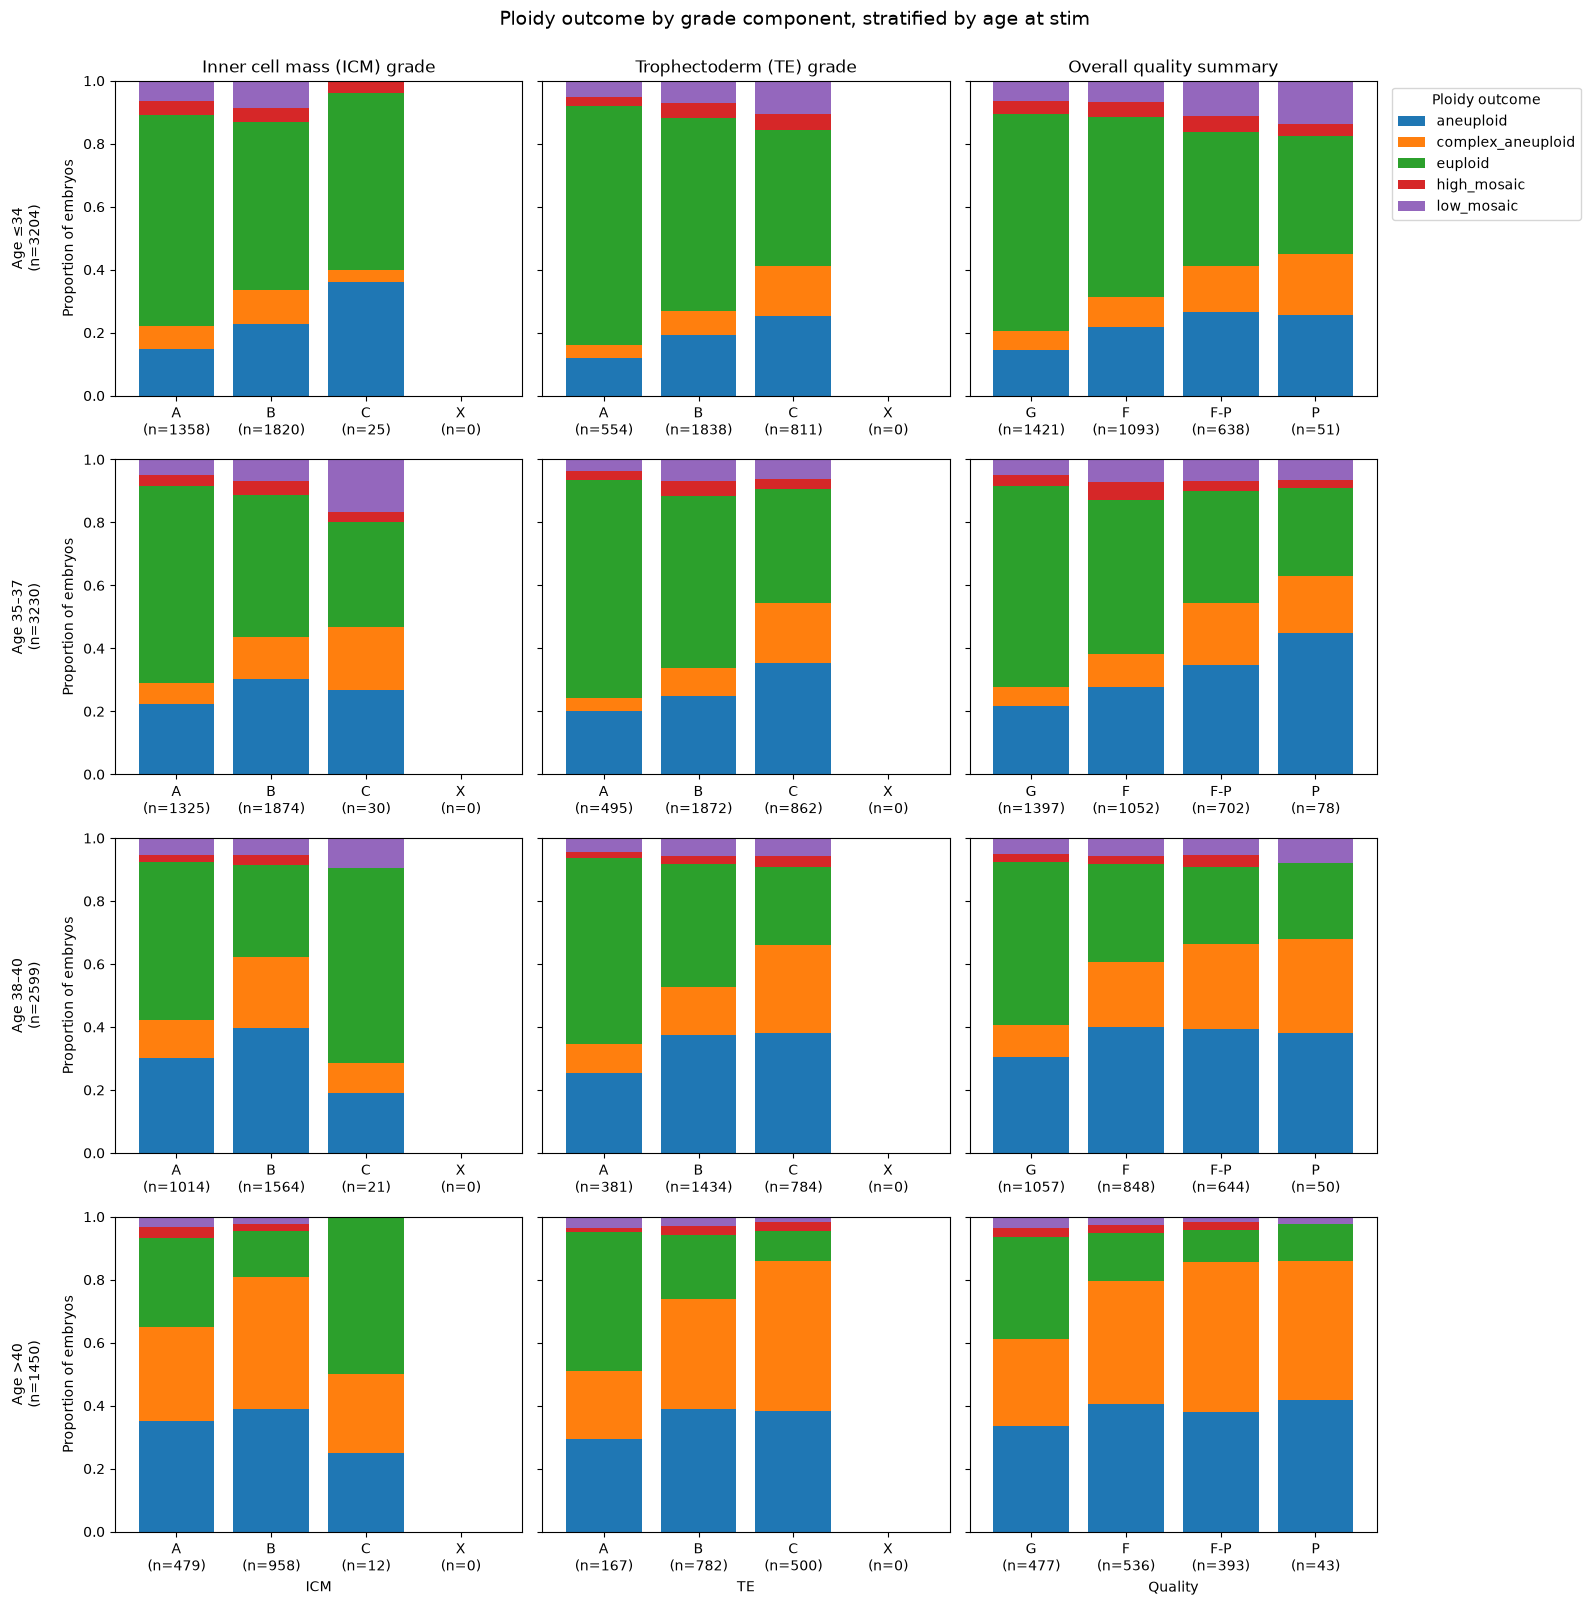

In [205]:
# now the above plot by age group
import matplotlib.pyplot as plt
import pandas as pd

# --- Split the grade into its three components ---
tested = tested.copy()
tested['icm']     = tested['grade'].str[0]              # A / B / C / X
tested['te']      = tested['grade'].str[1]              # A / B / C / X
tested['quality'] = tested['grade'].str.extract(r'(G|F-P|F|P)$')

# --- Age bands ---
age_bins   = [-float('inf'), 34, 37, 40, float('inf')]
age_labels = ['≤34', '35–37', '38–40', '>40']
tested['age_band'] = pd.cut(tested['age_at_stim'], bins=age_bins, labels=age_labels, right=True)

# Ordered categories (best -> worst)
icm_order     = ['A', 'B', 'C', 'X']
te_order      = ['A', 'B', 'C', 'X']
quality_order = ['G', 'F', 'F-P', 'P']

# Use the SAME outcome column order as the earlier plot so colors line up.
outcome_order = list(tab.columns)

def build_tables(sub, col, order):
    props  = pd.crosstab(sub[col], sub['ploidy_outcome'], normalize='index').reindex(order)
    counts = pd.crosstab(sub[col], sub['ploidy_outcome']).reindex(order)
    props  = props.reindex(columns=outcome_order, fill_value=0)
    return props, counts.sum(axis=1).fillna(0)

# --- Plot: 4 rows (age bands) x 3 cols (ICM / TE / Quality) ---
fig, axes = plt.subplots(4, 3, figsize=(16, 16), sharey=True)

col_specs = [
    ('icm',     icm_order,     "Inner cell mass (ICM) grade", "ICM"),
    ('te',      te_order,      "Trophectoderm (TE) grade",    "TE"),
    ('quality', quality_order, "Overall quality summary",     "Quality"),
]

for row_idx, age in enumerate(age_labels):
    sub = tested[tested['age_band'] == age]
    n_band = len(sub)
    for col_idx, (col, order, title, xlabel) in enumerate(col_specs):
        ax = axes[row_idx, col_idx]
        props, n = build_tables(sub, col, order)

        props.plot(kind='bar', stacked=True, ax=ax, width=0.8, legend=False)
        ax.set_xticklabels(
            [f"{g}\n(n={int(n.loc[g])})" for g in order],
            rotation=0,
        )
        ax.set_ylim(0, 1)
        ax.set_xlabel(xlabel if row_idx == len(age_labels) - 1 else "")

        # Column titles only on the top row
        if row_idx == 0:
            ax.set_title(title)

        # Row labels on the left
        if col_idx == 0:
            ax.set_ylabel(f"Age {age}\n(n={n_band})\n\nProportion of embryos")
        else:
            ax.set_ylabel("")

# Legend on the top-right panel
axes[0, -1].legend(title="Ploidy outcome", bbox_to_anchor=(1.02, 1), loc="upper left")

fig.suptitle("Ploidy outcome by grade component, stratified by age at stim", y=1.00, fontsize=14)
plt.tight_layout()
plt.show()